   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.8/63.8 MB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 101.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.5/307.5 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 99.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 362.3/362.3 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 90.5 MB/s eta 0:00:00


In [1]:
!pip install openpinch -q
import numpy as np
import matplotlib.pyplot as plt
from OpenPinch import pinch_analysis_service
print('OpenPinch listo.')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.8/63.8 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 99.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.5/307.5 kB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 109.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 314.1/314.1 kB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 91.5 MB/s eta 0:00:00
OpenPinch listo.


In [2]:
streams = [
    {'name': 'H1', 'zone': 'P', 't_supply': 75.0, 't_target': 44.0,  'heat_flow': 135.8, 'dt_cont': 2.5, 'htc': 0.5},
    {'name': 'H2', 'zone': 'P', 't_supply': 95.0, 't_target': 78.0,  'heat_flow': 180.7, 'dt_cont': 2.5, 'htc': 0.5},
    {'name': 'H3', 'zone': 'P', 't_supply': 44.0,  't_target': 36.0,  'heat_flow': 46.7, 'dt_cont': 2.5, 'htc': 0.5},
    {'name': 'H4', 'zone': 'P', 't_supply':73.3, 't_target': 40.0,  'heat_flow': 64.6, 'dt_cont': 2.5, 'htc': 0.5},
    {'name': 'H5', 'zone': 'P', 't_supply': 40.0, 't_target': 38.0,  'heat_flow': 7.8, 'dt_cont': 2.5, 'htc': 0.5},
    {'name': 'H6', 'zone': 'P', 't_supply': 62.4,  't_target': 25.0,  'heat_flow': 347.8, 'dt_cont': 2.5, 'htc': 0.5},
    {'name': 'H7', 'zone': 'P', 't_supply': 62.4,  't_target': 25.0,  'heat_flow': 482.5, 'dt_cont': 2.5, 'htc': 0.5},
    {'name': 'C1', 'zone': 'P', 't_supply': 12.2,  't_target': 95.0, 'heat_flow': 880.2, 'dt_cont': 2.5, 'htc': 0.5},
    {'name': 'C2', 'zone': 'P', 't_supply': 4.0,  't_target': 35.0, 'heat_flow': 135.8, 'dt_cont': 2.5, 'htc': 0.5},
    {'name': 'C3', 'zone': 'P', 't_supply': 35.0,  't_target': 75.0, 'heat_flow': 175.2, 'dt_cont': 2.5, 'htc': 0.5},
    {'name': 'C4', 'zone': 'P', 't_supply': 12.2,  't_target': 18.0, 'heat_flow': 36.83, 'dt_cont': 2.5, 'htc': 0.5},
    {'name': 'C5', 'zone': 'P', 't_supply': 12.2,  't_target': 38.0, 'heat_flow': 68.1, 'dt_cont': 2.5, 'htc': 0.5},
    {'name': 'C6', 'zone': 'P', 't_supply': 34.0,  't_target': 35.0, 'heat_flow': 3.89, 'dt_cont': 2.5, 'htc': 0.5},
]

result, zone = pinch_analysis_service({'streams': streams}, project_name='Demo', is_return_full_results=True)
t = result.targets[0]
Qh, Qc, Qr = float(t.Qh), float(t.Qc), float(t.Qr)
Tp = float(t.temp_pinch.cold_temp) if t.temp_pinch and t.temp_pinch.cold_temp else None
print(f'Qh_min = {Qh:.0f} kW  |  Qc_min = {Qc:.0f} kW  |  Qr = {Qr:.0f} kW  |  Tpinch = {Tp:.0f} °C')


Qh_min = 220 kW  |  Qc_min = 186 kW  |  Qr = 1080 kW  |  Tpinch = 60 °C


In [3]:
key = [k for k in zone.targets.keys() if 'Direct Integration' in k][0]
df = zone.targets[key].pt.to_dataframe
cols = [c for c in ['T', 'CP_NET', 'H_net'] if c in df.columns]
print('Problem Table (primeras 8 filas):')
display(df[cols].head(8).style.format("{:.1f}"))

Problem Table (primeras 8 filas):


,T,CP_NET,H_net
0,97.5,0.0,219.8
1,97.4,10.6,218.7
2,92.5,10.6,166.6
3,77.5,0.0,166.6
4,77.0,4.4,164.5
5,75.5,4.4,157.8
6,72.5,15.0,112.8
7,70.8,10.6,94.7


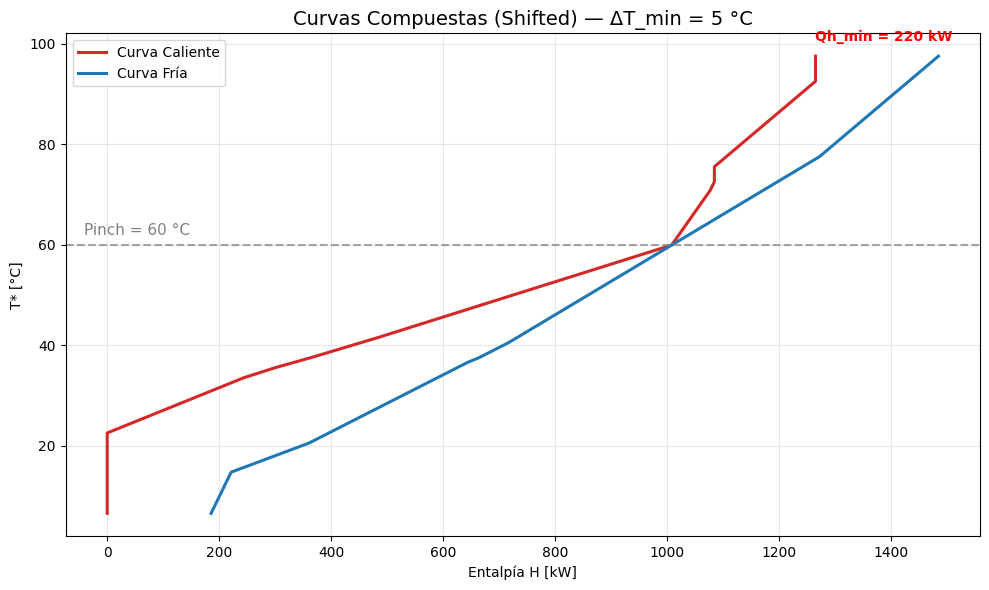

In [5]:
T  = df['T'].to_numpy()
Hh = df['H_hot'].to_numpy()
Hc = df['H_cold'].to_numpy()

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(Hh, T, color='#D62728', lw=2.2, label='Curva Caliente')
ax.plot(Hc, T, color='#1F77B4', lw=2.2, label='Curva Fría')
ax.axhline(y=Tp, color='gray', ls='--', alpha=0.7)
ax.text(0.02, Tp+2, f'Pinch = {Tp:.0f} °C', transform=ax.get_yaxis_transform(), fontsize=11, color='gray')
ax.annotate(f'Qh_min = {Qh:.0f} kW', xy=(Hh[0], T[0]+3), fontsize=10, color='red', fontweight='bold')
ax.annotate(f'Qc_min = {Qc:.0f} kW', xy=(Hh[-1], T[-1]-5), fontsize=10, color='blue', fontweight='bold')
ax.set_xlabel('Entalpía H [kW]'); ax.set_ylabel('T* [°C]')
ax.set_title('Curvas Compuestas (Shifted) — ΔT_min = 5 °C', fontsize=14)
ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

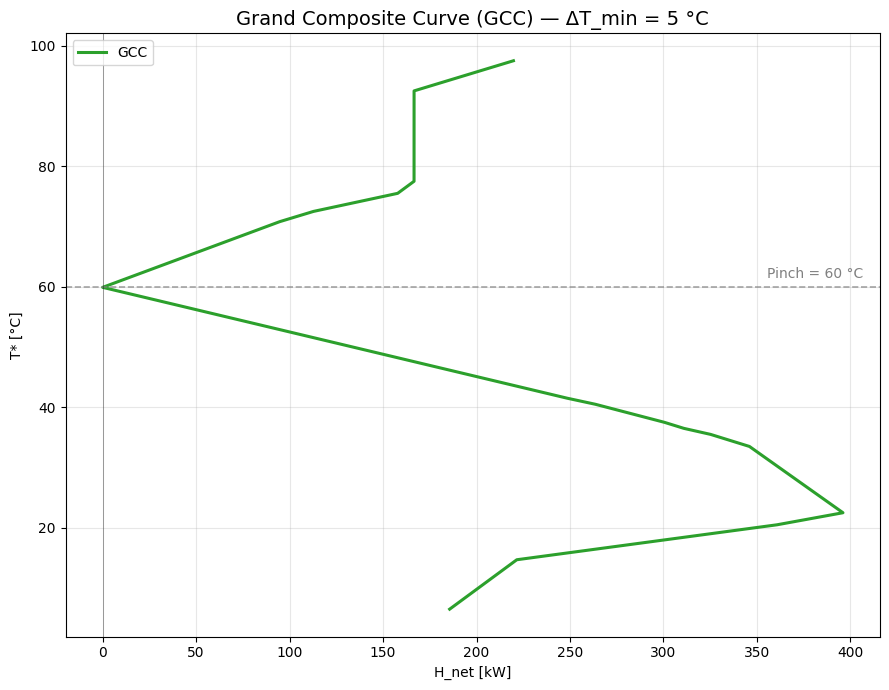

In [6]:
Hn = df['H_net'].to_numpy()

fig, ax = plt.subplots(figsize=(9, 7))
ax.plot(Hn, T, color='#2CA02C', lw=2.2, label='GCC')

# Anotaciones
ax.axhline(y=Tp, color='gray', ls='--', lw=1.2, alpha=0.7)
ax.text(0.98, Tp+1, f'Pinch = {Tp:.0f} °C', transform=ax.get_yaxis_transform(), fontsize=10, color='gray', va='bottom', ha='right')
ax.axvline(x=0, color='black', lw=0.6, alpha=0.4)
# Zona solar
ax.set_xlabel('H_net [kW]'); ax.set_ylabel('T* [°C]')
ax.set_title('Grand Composite Curve (GCC) — ΔT_min = 5 °C', fontsize=14)
ax.legend(loc='upper left'); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

In [7]:
def niveles_solares(T, H_net, T_pinch):
    """Retorna puntos (T*, Q_disp) sobre el Pinch con déficit neto."""
    pts = []
    for i in range(len(T)):
        if T[i] > T_pinch and H_net[i] > 1e-3:
            if len(pts) == 0 or abs(T[i] - pts[-1][0]) > 1.0:
                pts.append((T[i], H_net[i]))
    return pts

niv = niveles_solares(T, Hn, Tp)
print('Niveles de temperatura para integración solar (sobre el Pinch):')
if len(niv) == 0:
    print('  (Pinch en extremo superior — usar Qh_min completo.)')
    print(f'  Carga solar maxima = Qh_min = {Qh:.0f} kW')
    print(f'  T_suministro > {Tp:.0f} C (shifted)')
else:
    print(f'{"T* [C]":>10} {"Q_disp [kW]":>15}')
    print('-'*28)
    for ts, qd in niv:
        print(f'{ts:10.0f} {qd:15.0f}')
    print(f'\n{len(niv)} puntos candidatos.')
    best = max(niv, key=lambda x: x[1])
    print(f'Maxima carga: T* ~ {best[0]:.0f} C, Q ~ {best[1]:.0f} kW.')

Niveles de temperatura para integración solar (sobre el Pinch):
    T* [C]     Q_disp [kW]
----------------------------
        98             220
        92             167
        78             167
        76             158
        72             113
        71              95

6 puntos candidatos.
Maxima carga: T* ~ 98 C, Q ~ 220 kW.
